Загрузка модели и токенизатора... Это может занять некоторое время.
Используемое устройство: cuda

Генерация текста...

Расчет косинусного сходства...

Сгенерированный текст:
В далеком будущем, на планете Земля, в таинственной и неизвестной лаборатории, работал робот по имени "А

Построение графика...


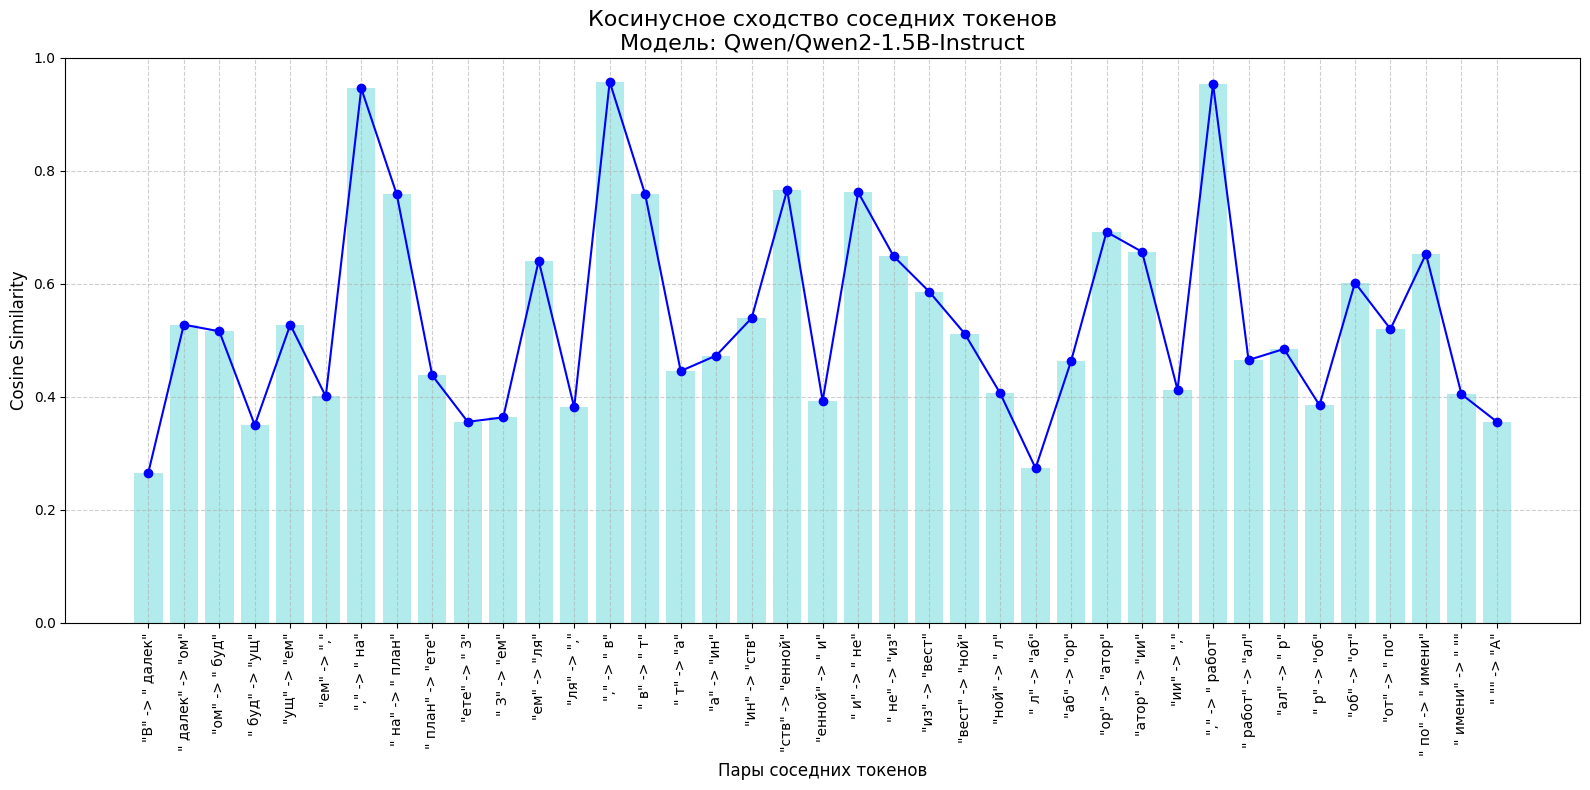

In [2]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import matplotlib.pyplot as plt
import numpy as np

# Убедимся, что matplotlib корректно отображает кириллицу
from matplotlib import rcParams

rcParams["font.family"] = "sans-serif"
rcParams["font.sans-serif"] = [
    "DejaVu Sans",
    "Arial",
    "Verdana",
]  # Шрифты с поддержкой кириллицы


def plot_adjacent_token_similarity(
    model_name: str, prompt: str, max_new_tokens: int = 50
):
    """
    Генерирует текст с помощью указанной модели, вычисляет косинусное сходство
    между соседними токенами и строит график.
    """
    print("Загрузка модели и токенизатора... Это может занять некоторое время.")

    # Определяем устройство (GPU, если доступно, иначе CPU)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Используемое устройство: {device}")

    # Загружаем модель и токенизатор
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype="auto",  # Может выбрать bfloat16, float16 или float32
        device_map="auto",
    )

    # Форматируем промпт согласно шаблону чата для Qwen2
    messages = [
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": prompt},
    ]
    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    # Токенизируем входной текст
    inputs = tokenizer(text, return_tensors="pt").to(device)
    prompt_length = inputs.input_ids.shape[1]

    print("\nГенерация текста...")
    # Генерируем текст и запрашиваем скрытые состояния (эмбеддинги)
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.7,
        top_k=50,
        output_hidden_states=True,
        return_dict_in_generate=True,
    )

    # --- Извлечение эмбеддингов сгенерированных токенов ---

    generated_ids = outputs.sequences[0, prompt_length:]

    generated_embeddings = []
    for i in range(len(outputs.hidden_states)):
        token_embedding = outputs.hidden_states[i][-1][0, -1, :].detach()
        generated_embeddings.append(token_embedding)

    generated_embeddings = torch.stack(generated_embeddings)

    print("\nРасчет косинусного сходства...")
    # --- Вычисление косинусного сходства между соседними токенами ---

    vecs1 = generated_embeddings[:-1]
    vecs2 = generated_embeddings[1:]

    similarities = torch.nn.functional.cosine_similarity(vecs1, vecs2, dim=1)

    # --- ИСПРАВЛЕНИЕ ЗДЕСЬ ---
    # Явно преобразуем тензор в float32 перед конвертацией в numpy
    similarities_np = similarities.to(torch.float32).cpu().numpy()

    # --- Подготовка данных для графика ---

    generated_tokens = [
        tokenizer.decode(token_id, skip_special_tokens=True)
        for token_id in generated_ids
    ]

    x_labels = []
    for i in range(len(generated_tokens) - 1):
        tok1 = generated_tokens[i].replace("$", "\\$")
        tok2 = generated_tokens[i + 1].replace("$", "\\$")
        x_labels.append(f'"{tok1}" -> "{tok2}"')

    full_text = tokenizer.decode(generated_ids, skip_special_tokens=True)
    print("\nСгенерированный текст:")
    print(full_text)

    print("\nПостроение графика...")
    # --- Построение графика ---
    plt.figure(figsize=(16, 8))

    x_values = np.arange(len(similarities_np))

    plt.plot(
        x_values,
        similarities_np,
        marker="o",
        linestyle="-",
        color="b",
        label="Cosine Similarity",
    )
    plt.bar(x_values, similarities_np, color="c", alpha=0.3, label="_nolegend_")

    plt.title(
        f"Косинусное сходство соседних токенов\nМодель: {model_name}", fontsize=16
    )
    plt.xlabel("Пары соседних токенов", fontsize=12)
    plt.ylabel("Cosine Similarity", fontsize=12)

    plt.xticks(x_values, x_labels, rotation=90, fontsize=10)
    plt.yticks(fontsize=10)

    plt.ylim(0, 1.0)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()


# --- Запуск ---
MODEL_NAME = "Qwen/Qwen2-1.5B-Instruct"
# Промпт, который провоцирует генерацию связного текста
PROMPT = "Расскажи короткую историю о роботе, который научился мечтать."

plot_adjacent_token_similarity(MODEL_NAME, PROMPT, max_new_tokens=40)